# Обучение моделей

Нами предложена двух модельная архитектура:

* **Простая** — логистическая регрессия на единственном признаке `contact_Число сделок`. Обучается на всех данных и используется для предсказания вероятности выкупа для старых клиентов
* **Продвинутая** — логистическая регрессия, обученная на наборе признаков новых клиентов

Качество финальной модели проверяется путем тренеровки на всех данных до февраля 2026 и тестировании ее на данных марта 2026

### Загрузка данных

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

from utils import (
    LogRegEncoder,
    best_f1_threshold,
    compute_classification_metrics,
    cumulative_months_loop,
    derive_feature_columns,
    load_feature_config,
    split_by_month,
)
from utils.plotting import (
    plot_cumulative_metrics,
    plot_feature_importance,
    plot_final_metrics_panels,
    plot_sigmoid_fit,
    plot_threshold_sweep,
    print_metrics,
)

DATA_DIR = Path('data')
CONFIG = 'features.yaml'
TARGET = 'buyout_flag'
FEAT_RET = 'contact_Число сделок'

config = load_feature_config(CONFIG)

clean = pd.read_csv(DATA_DIR / 'clean.csv', low_memory=False)
clean['sale_date'] = pd.to_datetime(clean['sale_date'], errors='coerce')

# available_columns=clean.columns — если в features.yaml есть признаки,
# пропущенные в ноутбуке 01 (например, закомментированы или у них нет
# source'а в сыром датасете), derive_feature_columns игнорирует их и
# строит FeatureColumns только по реально существующим колонкам.
feat_cols = derive_feature_columns(config, available_columns=clean.columns)
clean.shape


(17966, 26)

---

## Простая модель

In [2]:
clean_ts = clean.dropna(subset=['sale_date']).reset_index(drop=True)
train_ret, _ = split_by_month(clean_ts, train_through='2026-02', test_month='2026-03')
test_ret = clean_ts[
    (clean_ts['sale_date'].dt.to_period('M').astype(str) == '2026-03')
    & (clean_ts['is_new'] == 0)
]

X_tr_ret = train_ret[[FEAT_RET]].apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_ret = train_ret[TARGET].astype(int).values
X_te_ret = test_ret[[FEAT_RET]].apply(pd.to_numeric, errors='coerce').fillna(0)
y_te_ret = test_ret[TARGET].astype(int).values

pipe_ret = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000)),
])
pipe_ret.fit(X_tr_ret, y_tr_ret)
proba_ret = pipe_ret.predict_proba(X_te_ret)[:, 1]
metrics_ret = compute_classification_metrics(y_te_ret, proba_ret, threshold=0.5)
print(f'train rows = {len(train_ret)} (обе когорты)   test rows = {len(test_ret)} (повторные, март 2026)')
print_metrics(metrics_ret, title='Базовая модель — повторные клиенты, март 2026')


train rows = 16633 (обе когорты)   test rows = 1142 (повторные, март 2026)
Базовая модель — повторные клиенты, март 2026
| Метрика            | Значение                   |
|--------------------|----------------------------|
| Порог решения      | 0.50                       |
| Объём выборки      | 1142                       |
| Доля выкупа (факт) | 98.3%                      |
| Accuracy           | 98.3%                      |
| Balanced accuracy  | 50.0%                      |
| Precision          | 98.3%                      |
| Recall             | 100.0%                     |
| F1                 | 99.2%                      |
| Matthews corrcoef  | 0.0000                     |
| ROC-AUC            | 0.3488                     |
| PR-AUC             | 0.9790                     |
| Confusion matrix   | TN=0  FP=19  FN=0  TP=1123 |


Среди старых клиентов доля выкупа и без модели находится на уровне 98%, поэтому метрики модели почти упираются в потолок — модель просто подтверждает базовую частоту

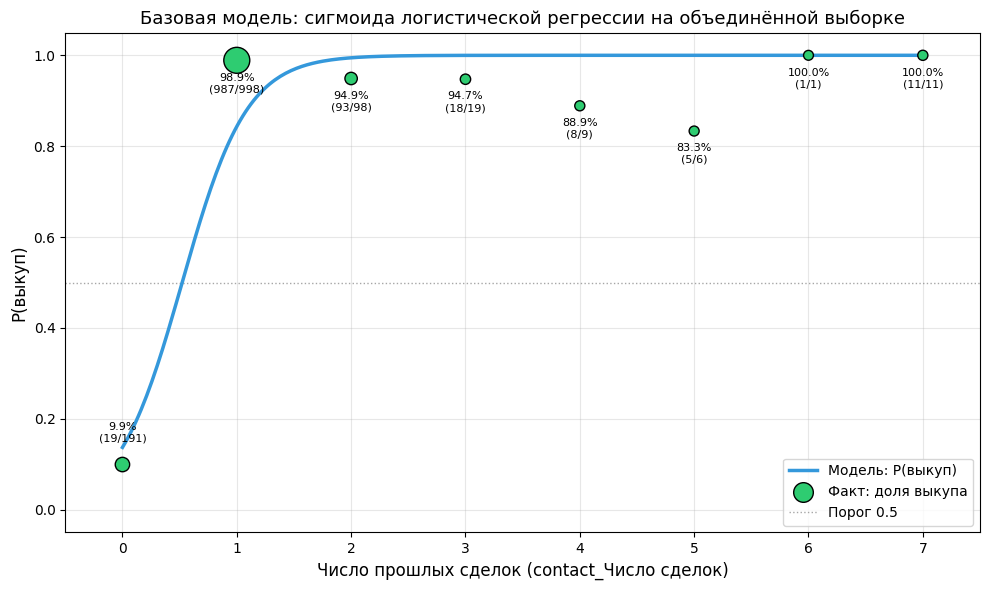

In [3]:
x_range = np.linspace(0, 7, 300)
proba_curve = pipe_ret.predict_proba(pd.DataFrame({FEAT_RET: x_range}))[:, 1]

# Фактические частоты считаем на обеих когортах в марте 2026 — иначе левый край
# сигмоиды (0 прошлых сделок) не с чем сравнить.
actuals = clean_ts[clean_ts['sale_date'].dt.to_period('M').astype(str) == '2026-03'].copy()
actuals['deals_int'] = pd.to_numeric(actuals[FEAT_RET], errors='coerce').fillna(0).clip(upper=7).astype(int)
actual_stats = actuals.groupby('deals_int')[TARGET].agg(['mean', 'sum', 'count'])
actual_stats.columns = ['buyout_rate', 'n_buyout', 'n_total']

plot_sigmoid_fit(
    x_range, proba_curve, actual_stats,
    xlabel='Число прошлых сделок (contact_Число сделок)',
    title='Базовая модель: сигмоида логистической регрессии на объединённой выборке',
)
plt.show()


На графике выше зелеными точками показана доля выкупа различных категорий клиентов по числу заказов (на test данных), синяя кривая показывает предсказание логистической регрессии. Видно, что модель проводит порог вероятности выкупа в `50%` в районе `0.5` число прошлых сделок. Таким образом, если клиент сделал ранее хотя бы `1` заказ, то вероятность того, что он выкупит товар близится к `100%`

---

## Продвинутая модель для новых клиентов

### Прогнозирование выкупа по месяцам

В данном подразделе было проверено, как логистическая регрессия справляется с предсказанием вероятности выкупа на месяц вперед. То есть для предсказания на месяц `M` модель была обучена на всех данных до этого месяца

In [4]:
new = clean[clean['is_new'] == 1].copy()
new = new.dropna(subset=['sale_date']).reset_index(drop=True)

def train_logreg(train_df, test_df):
    encoder = LogRegEncoder(feat_cols)
    X_tr = encoder.fit_transform(
        train_df[feat_cols.all_feature_cols], train_df[TARGET].values
    )
    X_te = encoder.transform(test_df[feat_cols.all_feature_cols])
    clf = LogisticRegression(
        class_weight='balanced', C=1.0, penalty='l2', max_iter=2000, solver='liblinear'
    )
    clf.fit(X_tr, train_df[TARGET].values)
    return clf.predict_proba(X_te)[:, 1]

results = cumulative_months_loop(new, train_logreg)


[2025-04] train=  524  test=  334  AUC=0.7758  bestF1=0.7668@0.38
[2025-05] train=  858  test=  287  AUC=0.8029  bestF1=0.7529@0.49
[2025-06] train= 1145  test=  292  AUC=0.8154  bestF1=0.7722@0.48
[2025-07] train= 1437  test=  328  AUC=0.8592  bestF1=0.8368@0.38
[2025-08] train= 1765  test=  446  AUC=0.7748  bestF1=0.7339@0.45
[2025-09] train= 2211  test=  354  AUC=0.8039  bestF1=0.7119@0.48
[2025-10] train= 2565  test=  376  AUC=0.8132  bestF1=0.5339@0.30
[2025-11] train= 2941  test=  259  AUC=0.5677  bestF1=0.2078@0.55
[2025-12] train= 3200  test=  195  AUC=0.5045  bestF1=0.2857@0.60
[2026-01] train= 3395  test=  289  AUC=0.6167  bestF1=0.2881@0.15
[2026-02] train= 3684  test=  322  AUC=0.7075  bestF1=0.3371@0.34
[2026-03] train= 4006  test=  191  AUC=0.7583  bestF1=0.3768@0.15


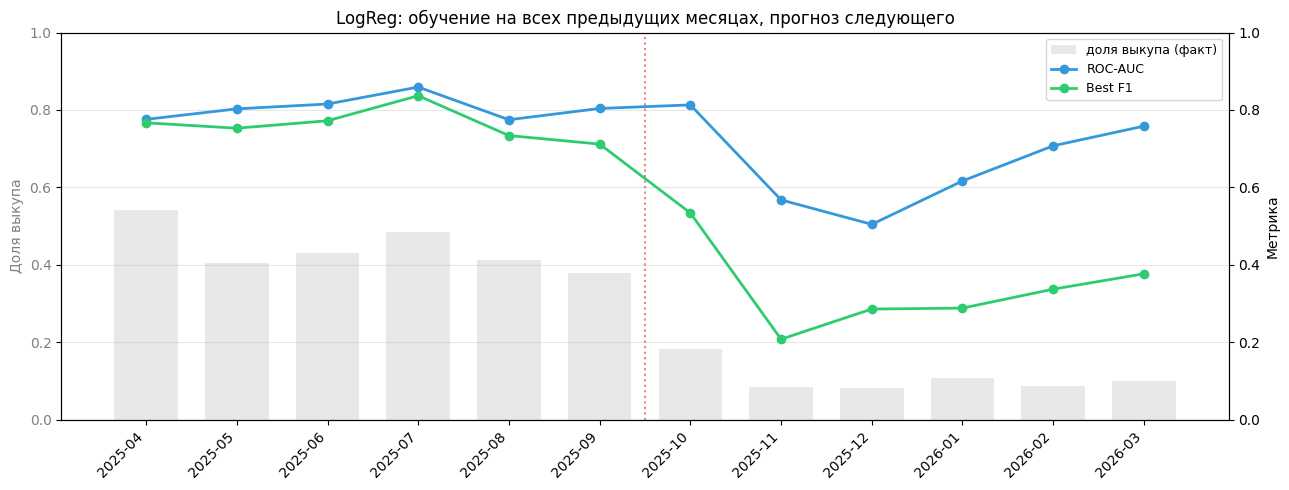

In [5]:
plot_cumulative_metrics(
    results,
    title='LogReg: обучение на всех предыдущих месяцах, прогноз следующего',
)
plt.show()


На графике выше показано, как менялась метрика ROC-AUC и максимально возможный F1 score для модели в зависимости от месяца `M`. Видно, что до **октября** 2025 года обе метрики показывали довольно хороший результат и положительную тенденцию. Однако, начиная с **октября** 2025 года предсказания модели резко просидает по всем показателям. Мы предполагаем, что это связано с тем, что поведение клиента кардинально меняется и модель, обученная на старых патернах, больше не релевантна. Также сильно скажывается образовавшийся дисбаланс классов.

Однако, стоит отметить, что при добавлении данных после **октября** 2025 в обучающую выборку видна тенденция улучшение качества модели и на момент марта 2026 метрика ROC-AUC почти вернулась на исходные значения (F1 по прежнему остается низкой из-за огромного дисбаланса классов).

### Метрики финальной модели

Под финальной моделью понимается логистическая регрессия, обученная на всех данных до февраля 2026

In [6]:
train_df, test_df = split_by_month(new, train_through='2026-02', test_month='2026-03')
print(f'train rows = {len(train_df)}   test rows = {len(test_df)}')

final_pipe = Pipeline([
    ('encoder', LogRegEncoder(feat_cols)),
    ('clf', LogisticRegression(
        class_weight='balanced', C=1.0, penalty='l2', max_iter=2000, solver='lbfgs'
    )),
])
X_train = train_df[feat_cols.all_feature_cols]
y_train = train_df[TARGET].astype(int).values
X_test = test_df[feat_cols.all_feature_cols]
y_test = test_df[TARGET].astype(int).values

final_pipe.fit(X_train, y_train)
proba_test = final_pipe.predict_proba(X_test)[:, 1]
best_f1, best_thr = best_f1_threshold(y_test, proba_test)
metrics_new = compute_classification_metrics(y_test, proba_test, threshold=best_thr)
print_metrics(metrics_new, title='Новые клиенты — март 2026 (финальная модель)')


train rows = 4006   test rows = 191
Новые клиенты — март 2026 (финальная модель)
| Метрика            | Значение                   |
|--------------------|----------------------------|
| Порог решения      | 0.15                       |
| Объём выборки      | 191                        |
| Доля выкупа (факт) | 9.9%                       |
| Accuracy           | 77.5%                      |
| Balanced accuracy  | 73.5%                      |
| Precision          | 26.0%                      |
| Recall             | 68.4%                      |
| F1                 | 37.7%                      |
| Matthews corrcoef  | 0.3194                     |
| ROC-AUC            | 0.7595                     |
| PR-AUC             | 0.2619                     |
| Confusion matrix   | TN=135  FP=37  FN=6  TP=13 |


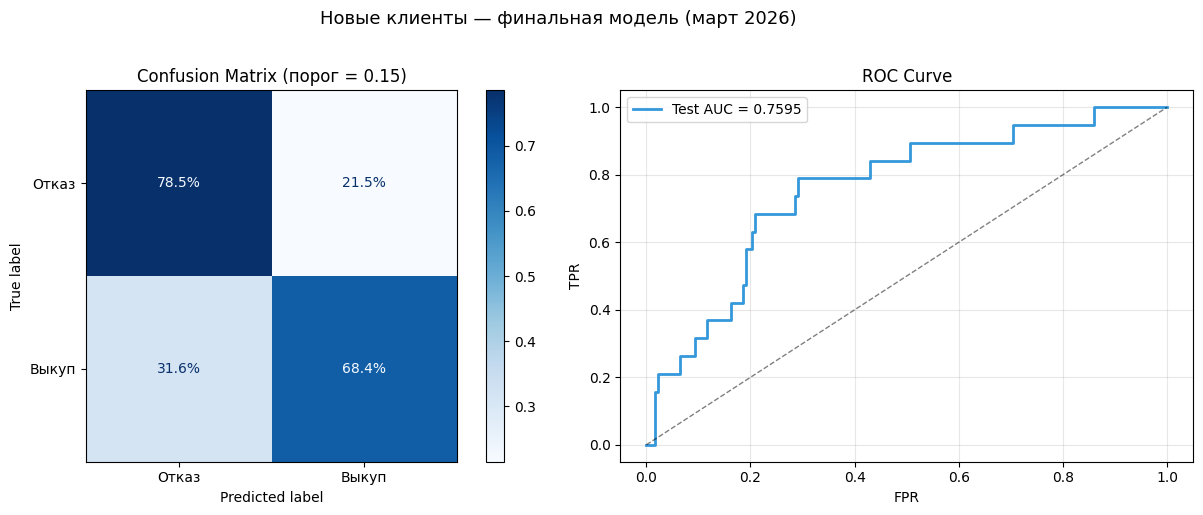

In [7]:
plot_final_metrics_panels(
    y_test, proba_test,
    threshold=best_thr,
    title='Новые клиенты — финальная модель (март 2026)',
)
plt.show()


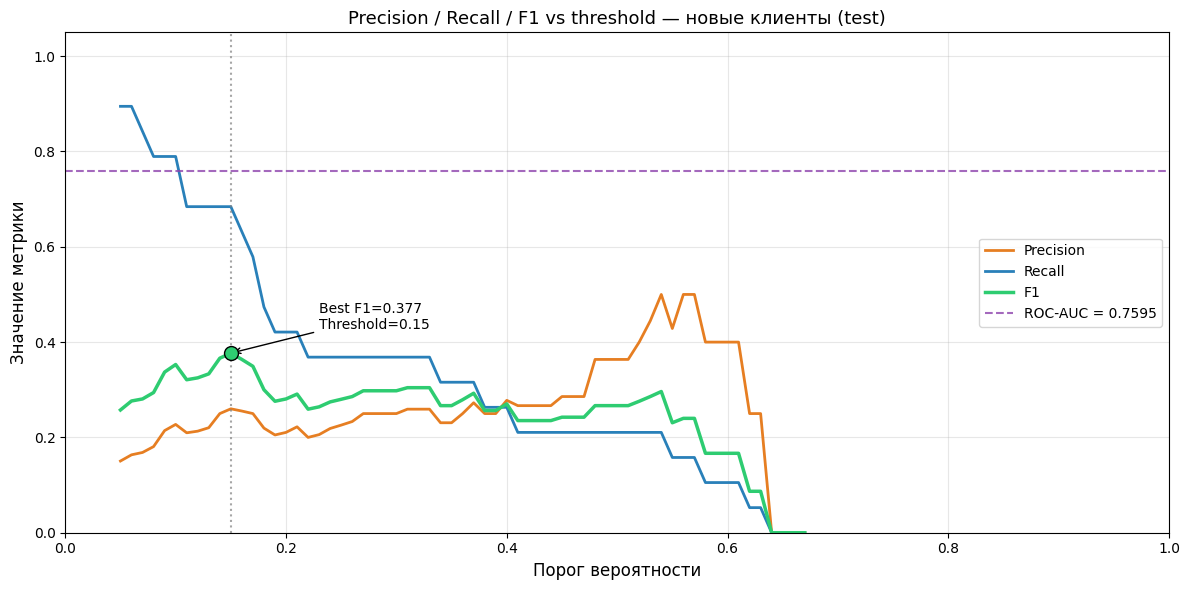

Лучший F1 = 0.3768  при пороге = 0.15


In [8]:
fig, best_t, best_f1_sweep = plot_threshold_sweep(
    y_test, proba_test,
    title='Precision / Recall / F1 vs threshold — новые клиенты (test)',
)
plt.show()
print(f'Лучший F1 = {best_f1_sweep:.4f}  при пороге = {best_t:.2f}')


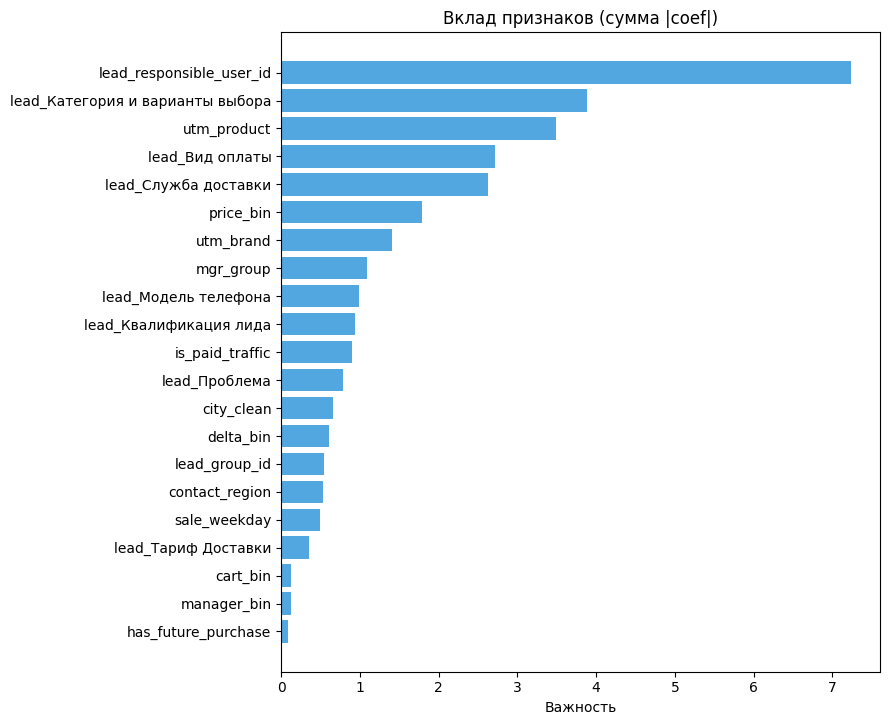

In [9]:
encoder = final_pipe.named_steps['encoder']
clf = final_pipe.named_steps['clf']
plot_feature_importance(
    clf.coef_[0],
    encoder.feature_names_,
    group_map=encoder.group_map_,
    top_n=25,
    title='Вклад признаков (сумма |coef|)',
)
plt.show()


Самые значимые признаки:
- *lead_responsible_user_id* – id менеджера, который вел клиента
- *lead_Вид_оплаты* – способо оплаты, который выбрал пользователь
- *lead_Категория и вариант выборы* – оценка покупателя по системе DISC
- *utm_product* – платформа с которой пришел клиент по рекламной ссылке
- *lead_Служба_доставки* – способ доставки товара клиенту
- *price_bin* – ценовая категория заказа
- ...

### Сохранение модели

In [10]:
joblib.dump(pipe_ret, DATA_DIR / 'logreg_returning.joblib')
joblib.dump(final_pipe, DATA_DIR / 'logreg_new.joblib')
with open(DATA_DIR / 'model_meta.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(
        {
            'threshold': float(best_thr),
            'train_through_month': '2026-02',
            'test_month': '2026-03',
            'feature_config': CONFIG,
        },
        f,
    )
print('Сохранено: logreg_returning.joblib, logreg_new.joblib, model_meta.yaml')


Сохранено: logreg_returning.joblib, logreg_new.joblib, model_meta.yaml


---

## Проверка `BuyoutPredictor` на всех данных за март

`BuyoutPredictor` - это продакшен модель, использующая под капотом логистическую регрессию для новых пользователей и простую модель для старых клиентов

In [11]:
from utils import load_raw_data, correct_historical_deal_count
from model import BuyoutPredictor

predictor = BuyoutPredictor(CONFIG, DATA_DIR)
raw = load_raw_data('dataset_2025-03-01_2026-03-29_external.csv')
raw = correct_historical_deal_count(raw)
march = raw[raw['sale_date'].dt.to_period('M').astype(str) == '2026-03']

proba_infer = predictor.predict_proba(march)
metrics_infer = compute_classification_metrics(
    march[TARGET].astype(int).values, proba_infer, threshold=predictor.threshold
)
print_metrics(metrics_infer, title='Инференс BuyoutPredictor — весь март 2026')


Инференс BuyoutPredictor — весь март 2026
| Метрика            | Значение                     |
|--------------------|------------------------------|
| Порог решения      | 0.15                         |
| Объём выборки      | 1333                         |
| Доля выкупа (факт) | 85.7%                        |
| Accuracy           | 95.3%                        |
| Balanced accuracy  | 85.1%                        |
| Precision          | 95.3%                        |
| Recall             | 99.5%                        |
| F1                 | 97.3%                        |
| Matthews corrcoef  | 0.7992                       |
| ROC-AUC            | 0.9310                       |
| PR-AUC             | 0.9785                       |
| Confusion matrix   | TN=135  FP=56  FN=6  TP=1136 |


Логистическая регрессия обучена → 03_advanced_models.ipynb